In [2]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().resolve().parent))

import numpy as np
import matplotlib.pyplot as plt
from napari import viewer
from skimage import filters
from skimage.morphology import disk, closing, opening
from skimage.measure import label
from scipy.ndimage import median_filter
from skimage.measure import regionprops
from xml.etree import ElementTree as ET
from aicsimageio import AICSImage
from scipy.optimize import curve_fit

from src.circularity import circ_filter
import src.circle_fitting as circle_fitting
from src.image_processing import watershed_segmentation
from src.image_processing import create_binary_mask

loading data

In [3]:
from aicsimageio import AICSImage
#rep1
img = AICSImage('/Users/taskina/2026_02_04_Will_paper/Will_droplet/rep1/Part_1_overnight/Experiment-305.czi')
#rep2
img2 = AICSImage('/Users/taskina/2026_02_04_Will_paper/Will_droplet/rep2/241130/Part1_overnight_until_morning/Experiment-128.czi')
# Check dimensions and scenes
print(img.dims)           # e.g., STCZYX
print(img2.dims)


<Dimensions [T: 49, C: 2, Z: 14, Y: 2048, X: 2048]>
<Dimensions [T: 59, C: 2, Z: 14, Y: 2048, X: 2048]>


In [4]:
Ims_mut_rep1 = []
for i in range(3):
    img.set_scene(img.scenes[i+3])
    Ims_mut_rep1.append(img.data[:,0,7,:,:])
    print(img.physical_pixel_sizes)

Ims_mut_rep2 = []

for i in [0, 1, 3, 4]:
    img2.set_scene(img2.scenes[i])
    lazy = img2.dask_data[:, 0, 7, :, :]
    
    # Find last valid timepoint
    valid_frames = []
    for t in range(lazy.shape[0]):
        try:
            frame = np.array(lazy[t])
            if frame.sum() > 0:  # has actual data
                valid_frames.append(frame)
            else:
                print(f"Scene {i}, t={t}: empty frame, stopping")
                break
        except Exception as e:
            print(f"Scene {i}, t={t}: error - {e}, stopping")
            break
    
    Ims_mut_rep2.append(np.array(valid_frames))
    print(f"Scene {i}: {len(valid_frames)} valid frames, pixel size: {img2.physical_pixel_sizes}")

PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 0, t=38: error - Not enough data read at offset 44643107616 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 0: 38 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 1, t=38: error - Not enough data read at offset 44794133760 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 1: 38 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 3, t=37: error - Not enough data read at offset 44028514432 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 3: 37 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 4, t=37: error - Not enough data read at offset 44055783200 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 4: 37 valid fram

In [5]:
Ims_rep1 = []
for i in range(3):
    img.set_scene(img.scenes[i])
    Ims_rep1.append(img.data[:,0,7,:,:])
    print(img.physical_pixel_sizes)

Ims_rep2 = []

for i in [2, 5, 6, 7]:
    img2.set_scene(img2.scenes[i])
    lazy = img2.dask_data[:, 0, 7, :, :]
    
    # Find last valid timepoint
    valid_frames = []
    for t in range(lazy.shape[0]):
        try:
            frame = np.array(lazy[t])
            if frame.sum() > 0:  # has actual data
                valid_frames.append(frame)
            else:
                print(f"Scene {i}, t={t}: empty frame, stopping")
                break
        except Exception as e:
            print(f"Scene {i}, t={t}: error - {e}, stopping")
            break
    
    Ims_rep2.append(np.array(valid_frames))
    print(f"Scene {i}: {len(valid_frames)} valid frames, pixel size: {img2.physical_pixel_sizes}")



PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 2, t=38: error - Not enough data read at offset 44936769824 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 2: 38 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 5, t=37: error - Not enough data read at offset 44202614304 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 5: 37 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 6, t=37: error - Not enough data read at offset 44353640448 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 6: 37 valid frames, pixel size: PhysicalPixelSizes(Z=7.0, Y=0.311962890625, X=0.311962890625)
Scene 7, t=37: error - Not enough data read at offset 44496276512 -> requested: 880 bytes, actually got 0 bytes., stopping
Scene 7: 37 valid fram

In [6]:
delta_t=1200
dx = img.physical_pixel_sizes.X


# Image segmentation

In [7]:
#parameters for segmentation
footprint_3d = disk(2)[np.newaxis, :, :]
se = disk(1)
min_d_ws = 3
disk_ws = 3

In [ ]:
#initialize napari viewer
view = viewer.Viewer()

In [8]:
def preprocess_and_segment(image_stack, footprint_3d, se):
    """Median filter -> Otsu threshold -> morphological open+close -> connected components."""
    filtered = median_filter(image_stack, footprint=footprint_3d)
    binary = create_binary_mask(filtered, method='threshold_otsu')[0]
    opened = np.array([opening(f, footprint=se) for f in binary])
    closed = np.array([closing(f, footprint=se) for f in opened])
    return label(closed, connectivity=2, background=0)


def segment_image_list(images, footprint_3d, se, view=False, tag=''):
    """Segment a list of image stacks and add to napari viewer."""
    all_labels = []
    for i, I in enumerate(images):
        I_labels = preprocess_and_segment(I, footprint_3d, se)
        all_labels.append(I_labels)
        if view:
            view.add_image(I, name=f'Original z=7, {tag} scene {i}')
            view.add_labels(I_labels, name=f'Labels, {tag} scene {i}')
    return all_labels


In [9]:
#choose view=view to see the segmentation
#in any case segmentation takes some time
Ims_labels_rep1 = segment_image_list(Ims_rep1, footprint_3d, se, view=False, tag='WT rep1')
Ims_labels_rep2 = segment_image_list(Ims_rep2, footprint_3d, se, view=False, tag='WT rep2')

Ims_mut_labels_rep1 = segment_image_list(Ims_mut_rep1, footprint_3d, se, view=False, tag='mut rep1')
Ims_mut_labels_rep2 = segment_image_list(Ims_mut_rep2, footprint_3d, se, view=False, tag='mut rep2')

# Fit circles to estimate radii overtime

not used for further analysis, just to see from which timestep the condensates stop fast growing due to transcription

In [12]:
def fit_and_visualize_circles(labels_list, n_timepoints,
                              min_d_ws, disk_ws, view, circ_thresh=0.8, tag=''):
    """Watershed -> circularity filter -> circle fit on each scene, returns radii per timepoint."""
    radii = [[] for _ in range(n_timepoints)]
    for i, I_labels in enumerate(labels_list):
        I_ws = [watershed_segmentation(f, min_distance=min_d_ws, disk_size=disk_ws) for f in I_labels]
        I_ws = [circ_filter(f, circularity_filter='manual',
                            circularity_threshold=circ_thresh, size_filter='none')[0] for f in I_ws]

        ellipse_shapes = []
        for t, circles in enumerate(circle_fitting.fit_circles_simple(f) for f in I_ws):
            for cy, cx, r, _ in circles:
                radii[t].append(r)
                ellipse_shapes.append(np.array([
                    [t, cy - r, cx - r], [t, cy - r, cx + r],
                    [t, cy + r, cx + r], [t, cy + r, cx - r],
                ]))
        if view:
            view.add_shapes(ellipse_shapes, shape_type='ellipse',
                        edge_color='red', face_color='transparent',
                        edge_width=1, name=f'circle_fits, {tag} scene {i}')
    return radii

In [13]:
n_timepoints = len(Ims_rep1[0])
radii_rep1 = fit_and_visualize_circles(Ims_labels_rep1, n_timepoints,
                                       min_d_ws, disk_ws, view=False,tag='WT rep1')
radii_rep2 = fit_and_visualize_circles(Ims_labels_rep2, n_timepoints,
                                       min_d_ws, disk_ws, view=False,tag='WT rep2')
radii_mut_rep1 = fit_and_visualize_circles(Ims_mut_labels_rep1, n_timepoints,
                                       min_d_ws, disk_ws, view=False, tag='mut rep1')
radii_mut_rep2 = fit_and_visualize_circles(Ims_mut_labels_rep2, n_timepoints,
                                       min_d_ws, disk_ws, view=False, tag='mut rep2')
 
 

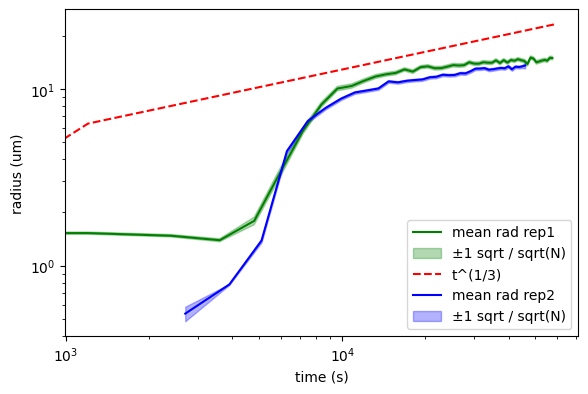

In [15]:
plt.figure(figsize=(6,4))

t = np.arange(50)*delta_t
t_rip = [0.6*t**(1/3) for t in t]

r_means = [np.mean(r*np.array(dx)) for r in radii_rep1][:]
r_stds = [np.std(r*np.array(dx)) for r in radii_rep1][:]
N = [len(r) for r in radii_rep1][:]

plt.plot(t[:len(r_means)], r_means[:], color='green', label='mean rad rep1')
plt.fill_between(t[:len(r_means)], np.array(r_means[:])-np.array(r_stds[:])/np.sqrt(N[:]),
                    np.array(r_means[:])+np.array(r_stds[:])/np.sqrt(N[:]),
                    alpha=0.3, color='green', label='±1 sqrt / sqrt(N)')

r_means = [np.mean(r*np.array(dx)) for r in radii_rep2][:]
r_stds = [np.std(r*np.array(dx)) for r in radii_rep2][:]
N = [len(r) for r in radii_rep2][:]
plt.plot(t[:], t_rip[:], color='r', linestyle='--',label='t^(1/3)')

t = np.arange(50)*delta_t+1500
plt.plot(t[:len(r_means)], r_means, color='blue', label='mean rad rep2')
plt.fill_between(t[:len(r_means)], np.array(r_means)-np.array(r_stds)/np.sqrt(N),
                    np.array(r_means)+np.array(r_stds)/np.sqrt(N),
                    alpha=0.3, color='blue', label='±1 sqrt / sqrt(N)')


plt.xlabel('time (s)')
plt.ylabel('radius (um)')
plt.legend()
plt.tight_layout()
plt.xscale('log')
plt.yscale('log')

# Fitting Ellipses

This part fits ellipses to the condensates to actually estimate aspect ratio.
Timeframe to start and labels of condensates used for fitting are chosen manually

In [10]:
label_ids = np.array([[810,974,401,488,201],[1077,76,679,628,100],[1008,1045,266,1351,420]])
t_starts = np.array([[24,23,20,20,36],[28,29,29,31,17],[21,21,35,19,19]])
#by hands from napari viewer

In [11]:
label_ids_rep2 = np.array([[443,280,245,226],[439,463,329,432],[415, 32, 123, 365],[506, 142, 212, 381]])
t_starts_rep2 = np.array([[29,26,25,15],[29,28,23,24],[19,26,31,23],[24,28,25,24]])

In [12]:
label_ids_mut_rep1 = np.array([[708,404,398, np.nan], [670, np.nan, np.nan, np.nan],[735,2523,364,614]])
t_starts_mut_rep1 = np.array([[15,17,10, np.nan], [9, np.nan, np.nan, np.nan], [12,14,24,32]])

In [13]:
label_ids_mut_rep2 = np.array([[1086,964,570], [576,517,398], [1296,203,261], [154,1456,1209]])
t_starts_mut_rep2 = np.array([[26,28,21], [24,24,24],[29,21,23], [31,29,31]])

In [16]:
from src.ellipse_analysis import (
    ellipse_polygon, linear, track_aspect_ratios,
    _fit_ar_decay, fit_single_label, fit_aspect_ratio_bulk,
)
from src.utils import plot_label_ellipse, visualize_ellipses

In [17]:
T_LEN = 6

# WT
aspect_ratios, ellipse_data_wt_rep1, char_l = track_aspect_ratios(
    Ims_labels_rep1, label_ids, t_starts, T_LEN, dx)
aspect_ratios_rep2, ellipse_data_wt_rep2, char_l_rep2 = track_aspect_ratios(
    Ims_labels_rep2, label_ids_rep2, t_starts_rep2, T_LEN, dx)

# Mut
aspect_ratios_mut_rep1, ellipse_data_mut_rep1, char_l_mut_rep1 = track_aspect_ratios(
    Ims_mut_labels_rep1, label_ids_mut_rep1, t_starts_mut_rep1, T_LEN, dx)
aspect_ratios_mut_rep2, ellipse_data_mut_rep2, char_l_mut_rep2 = track_aspect_ratios(
    Ims_mut_labels_rep2, label_ids_mut_rep2, t_starts_mut_rep2, T_LEN, dx)

In [27]:
np.save("aspect_ratios.npy", aspect_ratios)
np.save("aspect_ratios_rep2.npy", aspect_ratios_rep2)
np.save("aspect_ratios_mut_rep1.npy", aspect_ratios_mut_rep1)
np.save("aspect_ratios_mut_rep2.npy", aspect_ratios_mut_rep2)

In [ ]:
#run only if you want to add ellipses to napari viewer
visualize_ellipses(ellipse_data_wt_rep1, len(label_ids), view, tag='WT rep1')
visualize_ellipses(ellipse_data_wt_rep2, len(label_ids_rep2), view, tag='WT rep2')
visualize_ellipses(ellipse_data_mut_rep1, len(label_ids_mut_rep1), view, tag='mut rep1')
visualize_ellipses(ellipse_data_mut_rep2, len(label_ids_mut_rep2), view, tag='mut rep2')

AGX: exceeded compiled variants footprint limit


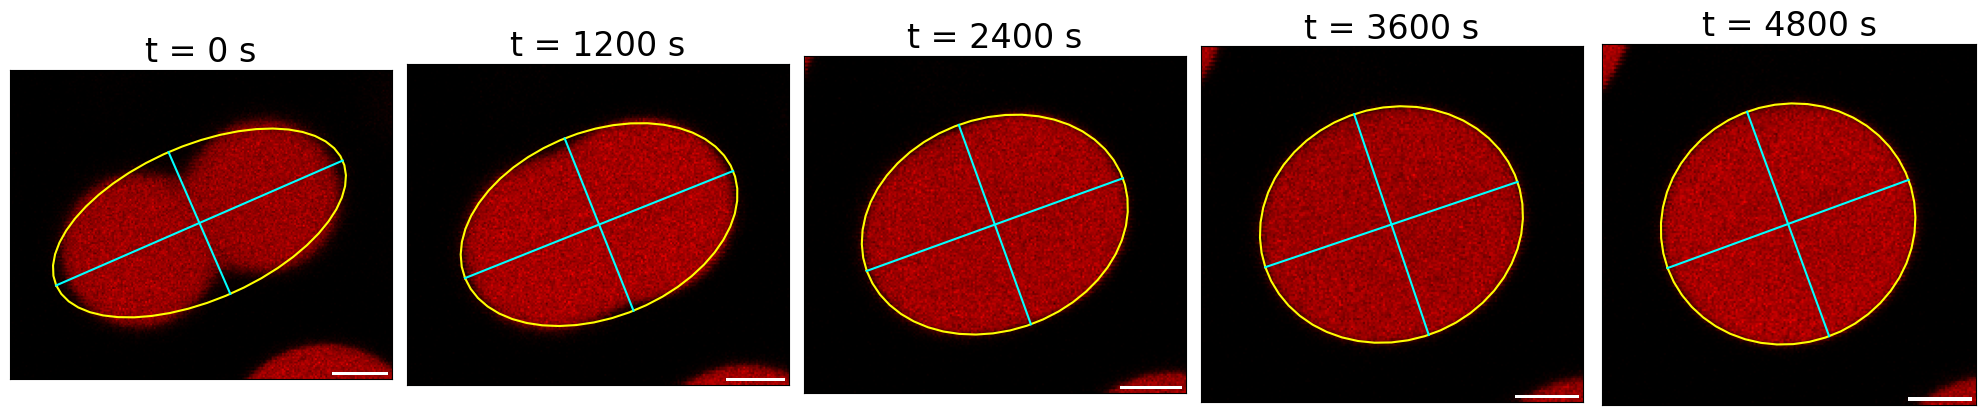

In [24]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib_scalebar.scalebar import ScaleBar

cmap_red = LinearSegmentedColormap.from_list('red', ['black', 'red'])

def make_scalebar():
    return ScaleBar(
        dx=dx, units="um", location="lower right",
        box_alpha=0, color="white",
        fixed_value=10, fixed_units="um",
        scale_loc="none", label_loc="none",
    )

scene, label_id, t_start, t_len = 0, 810, 24, 6
timesteps = range(t_start + 1, t_start + t_len)

fig, axes = plt.subplots(1, len(timesteps), figsize=(4 * len(timesteps), 4))
for i, (ax, t) in enumerate(zip(axes, timesteps)):
    plot_label_ellipse(
        raw_image=Ims_rep1[scene][t],
        label_image=Ims_labels_rep1[scene][t],
        label_id=label_id, cmap=cmap_red,
        major_color='cyan', minor_color='cyan', ax=ax
    )
    ax.set_title(f't = {i * delta_t} s', fontsize=24)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.add_artist(make_scalebar())
plt.tight_layout()
plt.savefig('../outputs/27_02_2026_ellipses.svg')

In [29]:
inv_taus = fit_aspect_ratio_bulk(aspect_ratios, delta_t, plot=False)
inv_taus_rep2 = fit_aspect_ratio_bulk(aspect_ratios_rep2, delta_t, plot=False)
inv_taus_mut_rep1 = fit_aspect_ratio_bulk(aspect_ratios_mut_rep1, delta_t, plot=False)
inv_taus_mut_rep2 = fit_aspect_ratio_bulk(aspect_ratios_mut_rep2, delta_t, plot=False)


tau values (s):
[[1813.42693138 1851.84459003 2457.00909711 2335.70147362 2550.46190707]
 [2195.9203814  1990.99205969 2201.46982282 2268.34621252 2523.68050378]
 [2520.84883819 2045.15189214 2357.94880069 3170.25737105 2954.40185887]]
tau values (s):
[[1366.12557054 1717.34246526 1792.36319632 1990.26379449]
 [1873.0654044  1492.22876009 1637.41186964 1598.05017013]
 [2194.28082225 1588.43673642 1453.8790182  2446.17684385]
 [ 970.69255316 1314.56615869 1668.74642812 1400.03286339]]
tau values (s):
[[3589.10961689 6051.87039495 2740.64916566           nan]
 [4842.62907639           nan           nan           nan]
 [4708.33494748 2338.91812105 8344.50606367 3447.86275162]]
tau values (s):
[[1464.25045155 1646.4817122  2773.35706192]
 [4828.03154652 2572.5756013  1272.01334664]
 [1450.46984842 3886.89062985 3340.8464849 ]
 [1968.42999592 1645.04806543 1805.58999043]]


In [28]:
np.save("inv_taus.npy", inv_taus)
np.save("inv_taus_rep2.npy", inv_taus_rep2)
np.save("inv_taus_mut_rep1.npy", inv_taus_mut_rep1)
np.save("inv_taus_mut_rep2.npy", inv_taus_mut_rep2)

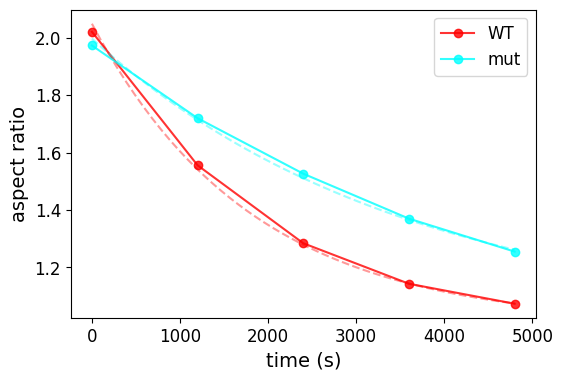

In [27]:
fig, ax = plt.subplots(figsize=(6, 4))
fit_single_label(aspect_ratios, 0, 0, delta_t, plot=True, axes=ax, plot_log=False, label='WT', color='red')
fit_single_label(aspect_ratios_mut_rep1, 0, 0, delta_t, plot=True, axes=ax, plot_log=False, label='mut', color='cyan')
ax.legend(fontsize=12)
ax.tick_params(labelsize=12)
ax.xaxis.label.set_size(14)
ax.yaxis.label.set_size(14)
plt.savefig('../outputs/26_02_26_taus.svg')

/var/folders/4c/77b_07tx55xb375_6pvqv3_r0000gp/T/ipykernel_68188/1678974356.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['rep1 WT', 'rep2 WT', 'rep1 mut', 'rep2 mut'])


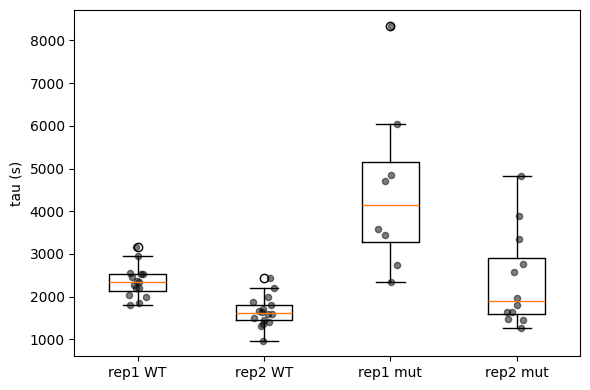

In [80]:
fig, ax = plt.subplots(figsize=(6, 4))

data = [1/inv_taus.flatten()[~np.isnan(inv_taus.flatten())],
        1/inv_taus_rep2.flatten()[~np.isnan(inv_taus_rep2.flatten())],
        1/inv_taus_mut_rep1.flatten()[~np.isnan(inv_taus_mut_rep1.flatten())],
        1/inv_taus_mut_rep2.flatten()[~np.isnan(inv_taus_mut_rep2.flatten())]]

bp = ax.boxplot(data, labels=['rep1 WT', 'rep2 WT', 'rep1 mut', 'rep2 mut'])

# Add scatter points
for i, d in enumerate(data, 1):
    x = np.random.normal(i, 0.04, size=len(d))
    ax.scatter(x, d, alpha=0.5, s=20, c='k')

ax.set_ylabel('tau (s)')
plt.tight_layout()

In [31]:
def fit_linear(l, a, b):
    return a*l+b

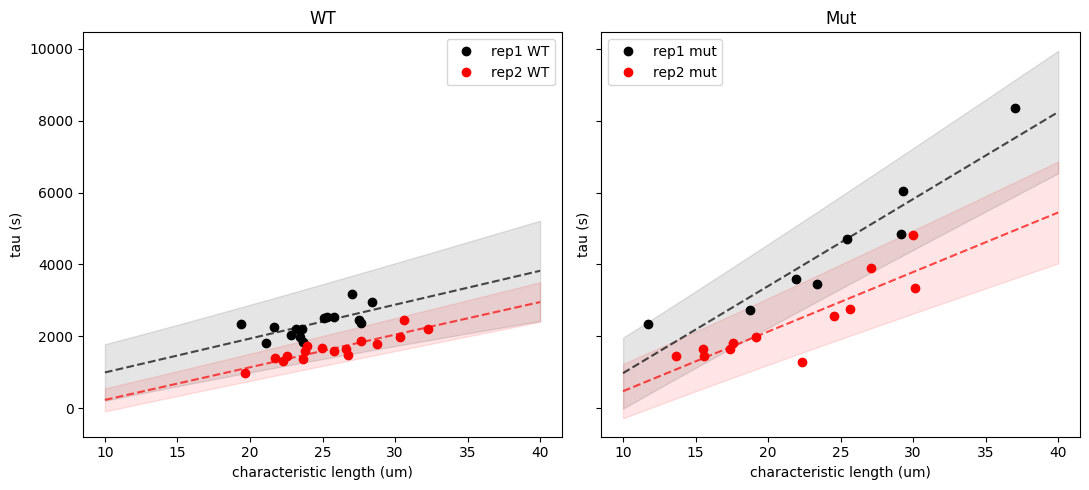

In [34]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5), sharex='col', sharey='row')

axs[0].plot(char_l.flatten()/2, 1/inv_taus.flatten(), 'o', label='rep1 WT', c='k')
axs[0].plot(char_l_rep2.flatten()/2, 1/inv_taus_rep2.flatten(), 'o', label='rep2 WT', c='r')
axs[1].plot(char_l_mut_rep1.flatten()[~np.isnan(char_l_mut_rep1.flatten())]/2, 1/inv_taus_mut_rep1.flatten()[~np.isnan(inv_taus_mut_rep1.flatten())], 'o', label='rep1 mut', c='k')
axs[1].plot(char_l_mut_rep2.flatten()/2, 1/inv_taus_mut_rep2.flatten(), 'o', label='rep2 mut', c='r')

popt, pcov = curve_fit(fit_linear, char_l.flatten()/2, 1/inv_taus.flatten())
popt_rep2, pcov_rep2 = curve_fit(fit_linear, char_l_rep2.flatten()/2, 1/inv_taus_rep2.flatten())
popt_mut_rep1, pcov_mut_rep1 = curve_fit(fit_linear, char_l_mut_rep1.flatten()[~np.isnan(char_l_mut_rep1.flatten())]/2, 1/inv_taus_mut_rep1.flatten()[~np.isnan(inv_taus_mut_rep1.flatten())])
popt_mut_rep2, pcov_mut_rep2 = curve_fit(fit_linear, char_l_mut_rep2.flatten()/2, 1/inv_taus_mut_rep2.flatten())
perr = np.sqrt(np.diag(pcov))
perr_rep2 = np.sqrt(np.diag(pcov_rep2))
perr_mut_rep1 = np.sqrt(np.diag(pcov_mut_rep1))
perr_mut_rep2 = np.sqrt(np.diag(pcov_mut_rep2))

l_fit = np.linspace(10, 40, 50)
axs[0].plot(l_fit, fit_linear(l_fit, *popt), '--', c='k', alpha=0.7)
axs[0].plot(l_fit, fit_linear(l_fit, *popt_rep2), '--', c='r', alpha=0.7)
axs[1].plot(l_fit, fit_linear(l_fit, *popt_mut_rep1), '--', c='k', alpha=0.7)
axs[1].plot(l_fit, fit_linear(l_fit, *popt_mut_rep2), '--', c='r', alpha=0.7)

sig = np.sqrt((l_fit * perr[0])**2 + perr[1]**2)
sig_rep2 = np.sqrt((l_fit * perr_rep2[0])**2 + perr_rep2[1]**2)
sig_mut_rep1 = np.sqrt((l_fit * perr_mut_rep1[0])**2 + perr_mut_rep1[1]**2)
sig_mut_rep2 = np.sqrt((l_fit * perr_mut_rep2[0])**2 + perr_mut_rep2[1]**2)

axs[0].fill_between(l_fit, fit_linear(l_fit, *popt)-sig, fit_linear(l_fit, *popt)+sig, alpha=0.1, color='k')
axs[0].fill_between(l_fit, fit_linear(l_fit, *popt_rep2)-sig_rep2, fit_linear(l_fit, *popt_rep2)+sig_rep2, alpha=0.1, color='r')
axs[1].fill_between(l_fit, fit_linear(l_fit, *popt_mut_rep1)-sig_mut_rep1, fit_linear(l_fit, *popt_mut_rep1)+sig_mut_rep1, alpha=0.1, color='k')
axs[1].fill_between(l_fit, fit_linear(l_fit, *popt_mut_rep2)-sig_mut_rep2, fit_linear(l_fit, *popt_mut_rep2)+sig_mut_rep2, alpha=0.1, color='r')


axs[0].set_xlabel('characteristic length (um)')
axs[0].set_ylabel('tau (s)')
axs[1].set_xlabel('characteristic length (um)')
axs[1].set_ylabel('tau (s)')

axs[0].legend()
axs[1].legend()

axs[0].set_title('WT')
axs[1].set_title('Mut')

plt.tight_layout()

#fig.savefig('tau_vs_char_length.svg', bbox_inches='tight')

In [29]:
np.save("char_l.npy", char_l)
np.save("char_l_rep2.npy", char_l_rep2)
np.save("char_l_mut_rep1.npy", char_l_mut_rep1)
np.save("char_l_mut_rep2.npy", char_l_mut_rep2)


WT slope:  63.70 ± 27.12
Mut slope: 231.96 ± 34.85


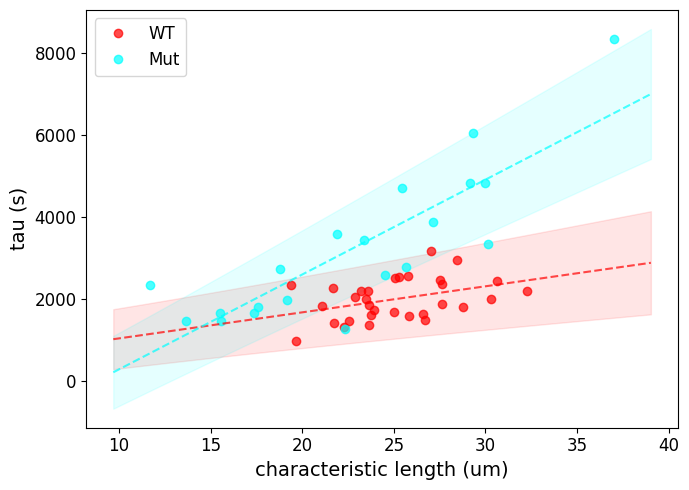

In [33]:
# Pool replicates
cl_wt = np.concatenate([char_l.flatten(), char_l_rep2.flatten()]) / 2
tau_wt = 1 / np.concatenate([inv_taus.flatten(), inv_taus_rep2.flatten()])
cl_mut = np.concatenate([char_l_mut_rep1.flatten(), char_l_mut_rep2.flatten()]) / 2
tau_mut = 1 / np.concatenate([inv_taus_mut_rep1.flatten(), inv_taus_mut_rep2.flatten()])

# Drop NaN
mask_wt = ~(np.isnan(cl_wt) | np.isnan(tau_wt))
mask_mut = ~(np.isnan(cl_mut) | np.isnan(tau_mut))
cl_wt, tau_wt = cl_wt[mask_wt], tau_wt[mask_wt]
cl_mut, tau_mut = cl_mut[mask_mut], tau_mut[mask_mut]

# Fit
popt_wt, pcov_wt = curve_fit(fit_linear, cl_wt, tau_wt)
popt_mut, pcov_mut = curve_fit(fit_linear, cl_mut, tau_mut)
perr_wt = np.sqrt(np.diag(pcov_wt))
perr_mut = np.sqrt(np.diag(pcov_mut))

l_fit = np.linspace(min(cl_wt.min(), cl_mut.min()) - 2,
                    max(cl_wt.max(), cl_mut.max()) + 2, 50)

fig, ax = plt.subplots(figsize=(7, 5))

ax.plot(cl_wt, tau_wt, 'o', c='r', label='WT', alpha=0.7)
ax.plot(cl_mut, tau_mut, 'o', c='cyan', label='Mut', alpha=0.7)

ax.plot(l_fit, fit_linear(l_fit, *popt_wt), '--', c='r', alpha=0.7)
ax.plot(l_fit, fit_linear(l_fit, *popt_mut), '--', c='cyan', alpha=0.7)

sig_wt = np.sqrt((l_fit * perr_wt[0])**2 + perr_wt[1]**2)
sig_mut = np.sqrt((l_fit * perr_mut[0])**2 + perr_mut[1]**2)
ax.fill_between(l_fit, fit_linear(l_fit, *popt_wt) - sig_wt,
                fit_linear(l_fit, *popt_wt) + sig_wt, alpha=0.1, color='red')
ax.fill_between(l_fit, fit_linear(l_fit, *popt_mut) - sig_mut,
                fit_linear(l_fit, *popt_mut) + sig_mut, alpha=0.1, color='cyan')

ax.set_xlabel('characteristic length (um)', fontsize=14)
ax.set_ylabel('tau (s)', fontsize=14)
ax.tick_params(labelsize=12)
ax.legend(fontsize=12)
plt.tight_layout()

print(f"WT slope:  {popt_wt[0]:.2f} ± {perr_wt[0]:.2f}")
print(f"Mut slope: {popt_mut[0]:.2f} ± {perr_mut[0]:.2f}")

plt.savefig('../outputs/26_02_26_tau_vs_char_length.svg', bbox_inches='tight')